<a href="https://colab.research.google.com/github/sandhyasrigajula-commits/Palo-Alto-Networks/blob/main/Palo_Alto_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
file_path = '/content/drive/MyDrive/Palo Alto Networks.csv'

In [5]:
df = pd.read_csv(file_path)

In [6]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2


In [7]:
df.shape

(1470, 31)

In [8]:
print(df.columns.tolist())

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int64 
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [10]:
missing_values = df.isnull().sum()
print(missing_values[missing_values >0])

Series([], dtype: int64)


In [11]:
print('duplicated rows',df.duplicated().sum())

duplicated rows 0


In [12]:
print(df['Attrition'].value_counts)

<bound method IndexOpsMixin.value_counts of 0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition, Length: 1470, dtype: int64>


In [13]:
print(df['Attrition'].value_counts(normalize=True) * 100)

Attrition
0    83.877551
1    16.122449
Name: proportion, dtype: float64


In [14]:
df.describe()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,0.161224,802.485714,9.192517,2.912925,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,0.367863,403.509100,8.106864,1.024165,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,0.000000,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,465.000000,2.000000,2.000000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,0.000000,802.000000,7.000000,3.000000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,0.000000,1157.000000,14.000000,4.000000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1.000000,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [15]:
numerical_columns= df.select_dtypes(include='number').columns.tolist()
print(numerical_columns)
df[numerical_columns].describe().T

['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
Attrition,1470.0,0.161224,0.367863,0.0,0.0,0.0,0.00,1.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.00,5.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.0,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.00,4.0


In [16]:
categorical_columns= df.select_dtypes(include='object').columns.tolist()
print(categorical_columns)
for column in categorical_columns:
  print("\n" + "=" *60)
  print(column)
print(df[column].value_counts())

['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

BusinessTravel

Department

EducationField

Gender

JobRole

MaritalStatus

OverTime
OverTime
No     1054
Yes     416
Name: count, dtype: int64


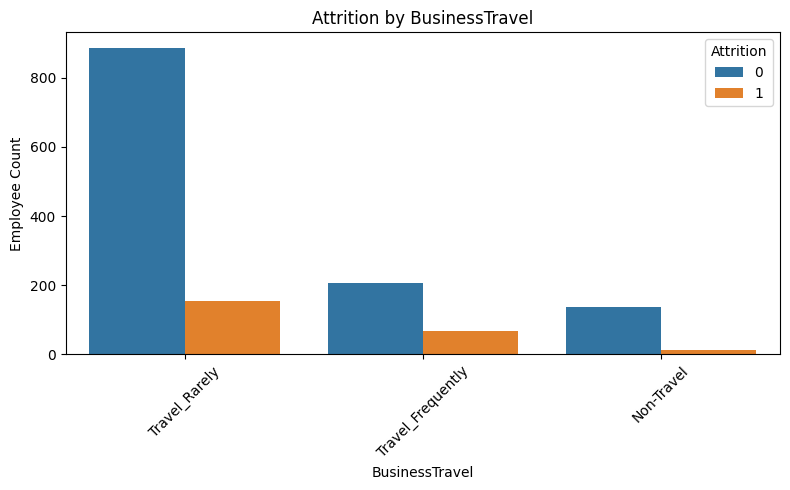

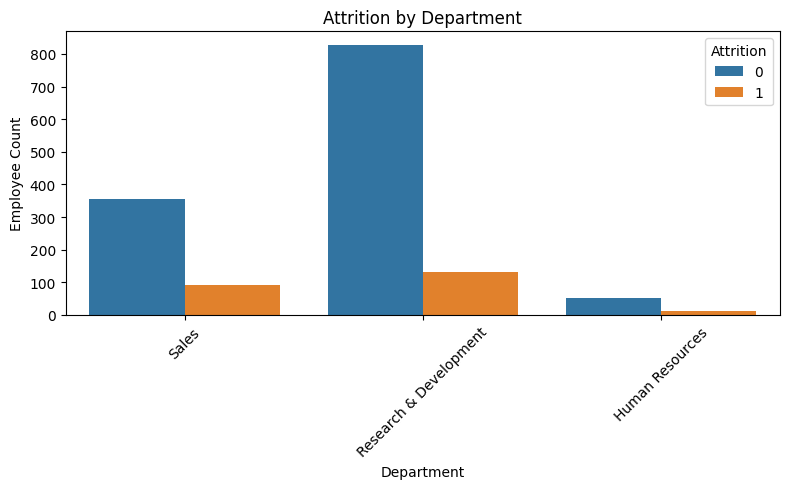

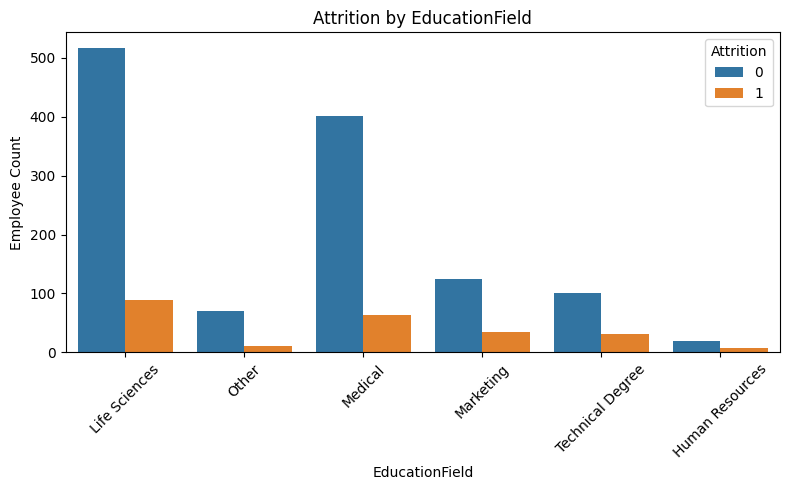

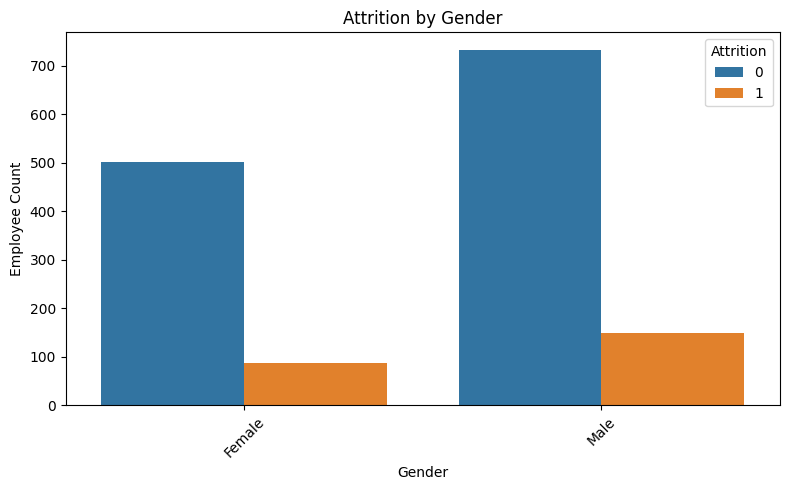

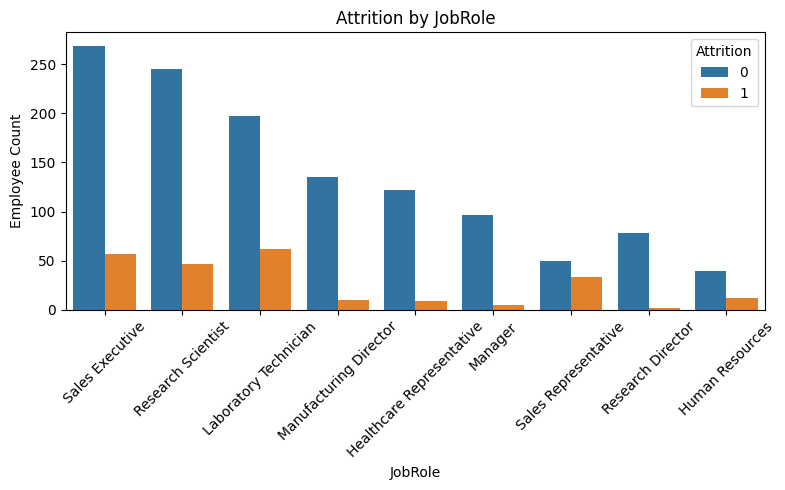

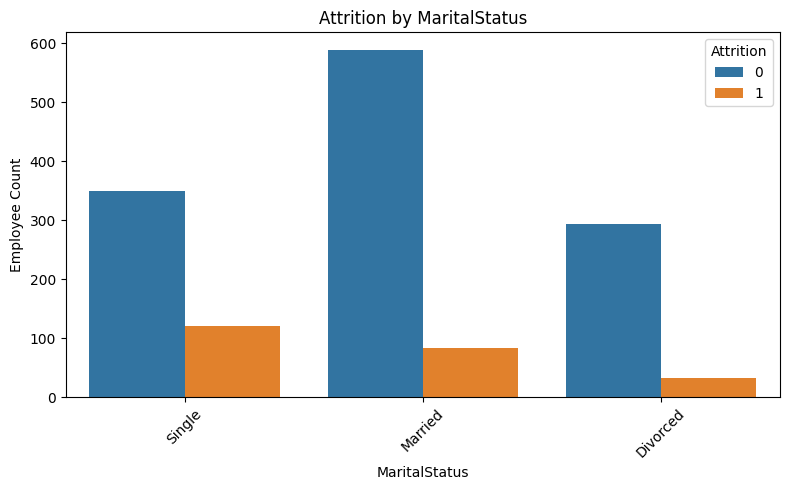

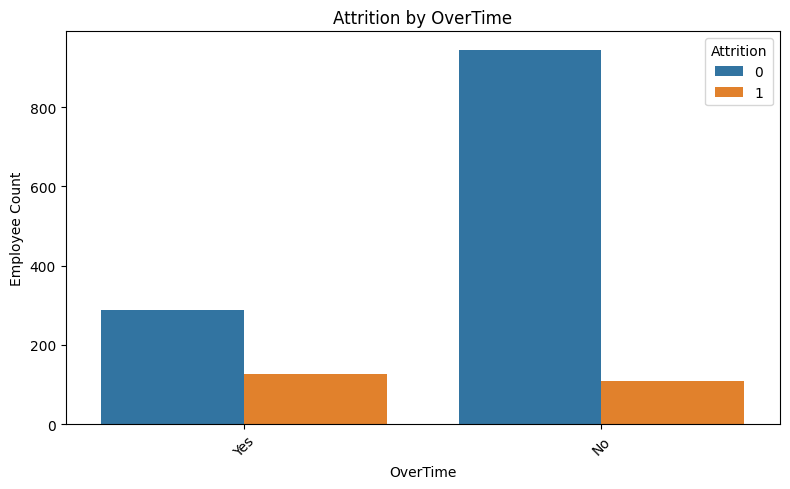

In [17]:
# ============================================================
 #CATEGORICAL VARIABLES VS ATTRITION
# ============================================================

for column in categorical_columns:

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x=column,
        hue="Attrition"
    )

    plt.title(f"Attrition by {column}")
    plt.xlabel(column)
    plt.ylabel("Employee Count")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [18]:
# ============================================================
# 10. ATTRITION RATE BY CATEGORICAL VARIABLES
# ============================================================

for column in categorical_columns:

    attrition_rate = (
        df.groupby(column)["Attrition"]
        .mean()
        .sort_values(ascending=False) * 100
    )

    print("\n" + "=" * 60)
    print(f"Attrition Rate by {column}")
    print(attrition_rate.round(2))


Attrition Rate by BusinessTravel
BusinessTravel
Travel_Frequently    24.91
Travel_Rarely        14.96
Non-Travel            8.00
Name: Attrition, dtype: float64

Attrition Rate by Department
Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64

Attrition Rate by EducationField
EducationField
Human Resources     25.93
Technical Degree    24.24
Marketing           22.01
Life Sciences       14.69
Medical             13.58
Other               13.41
Name: Attrition, dtype: float64

Attrition Rate by Gender
Gender
Male      17.01
Female    14.80
Name: Attrition, dtype: float64

Attrition Rate by JobRole
JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director   

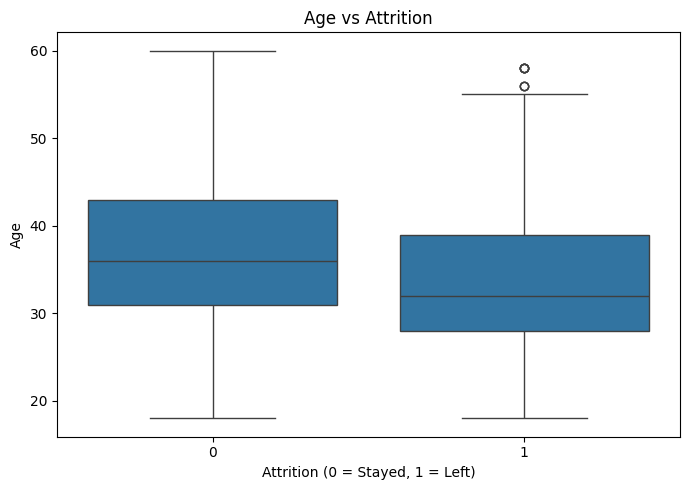

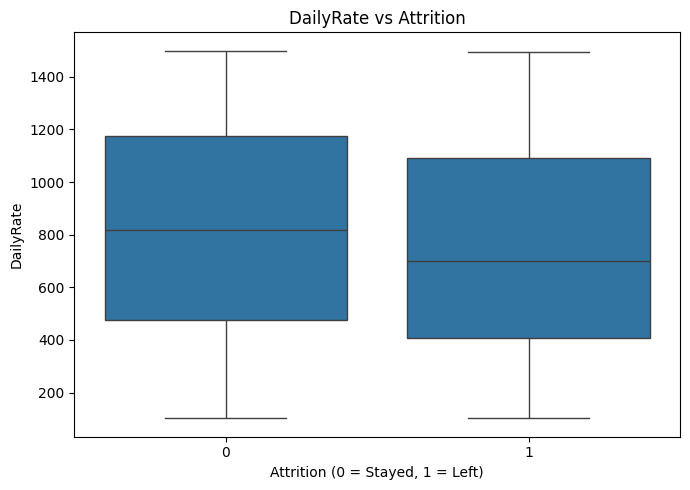

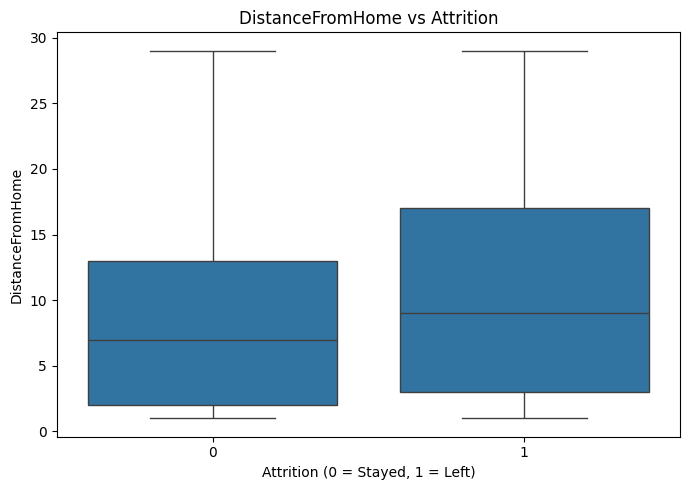

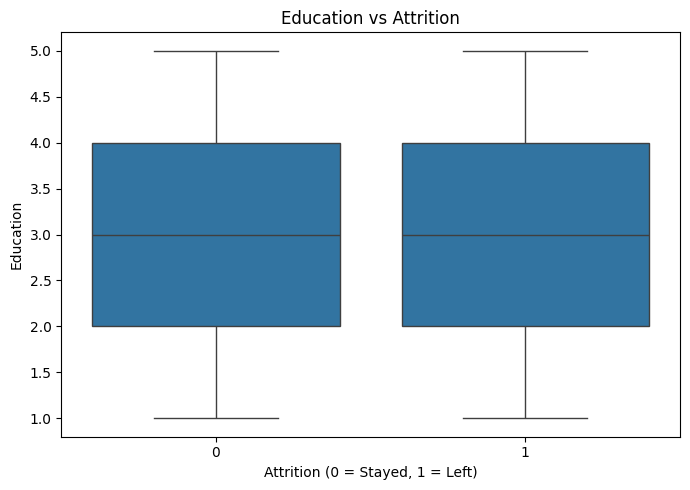

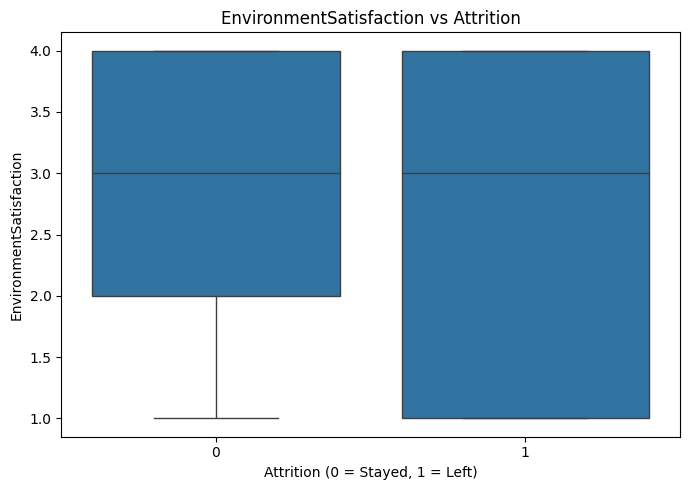

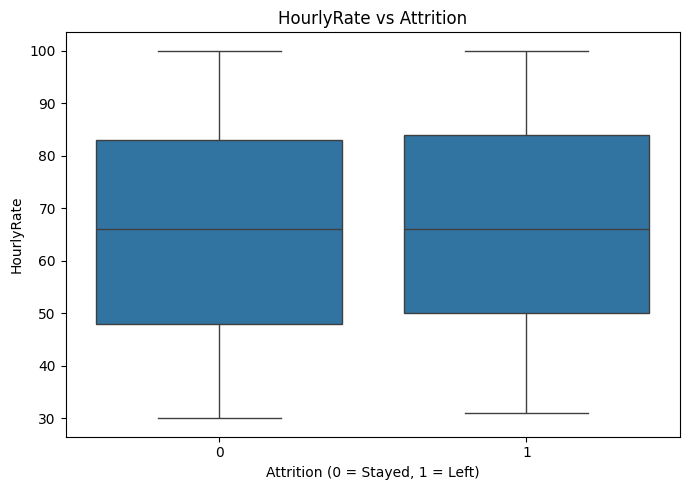

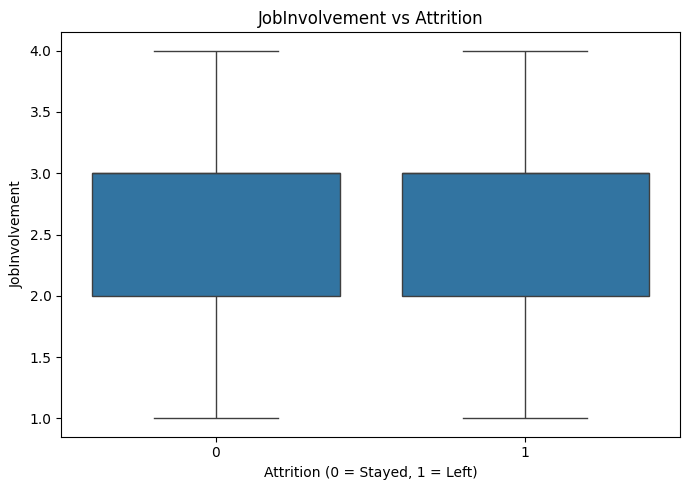

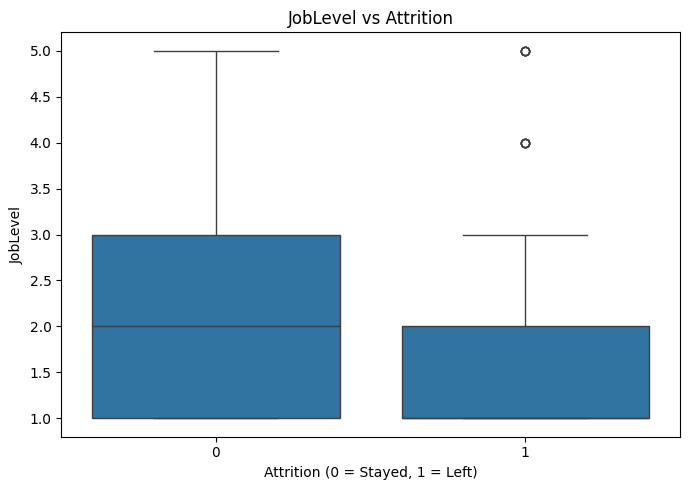

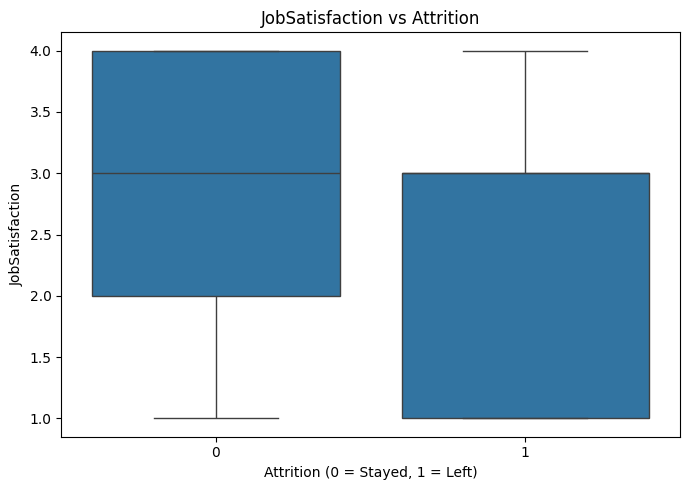

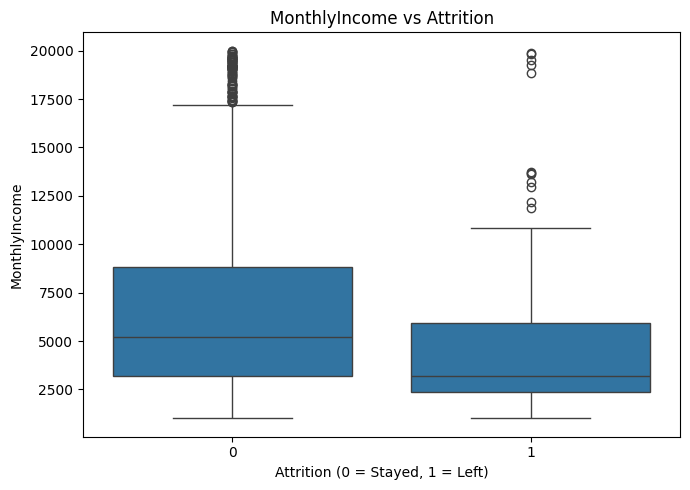

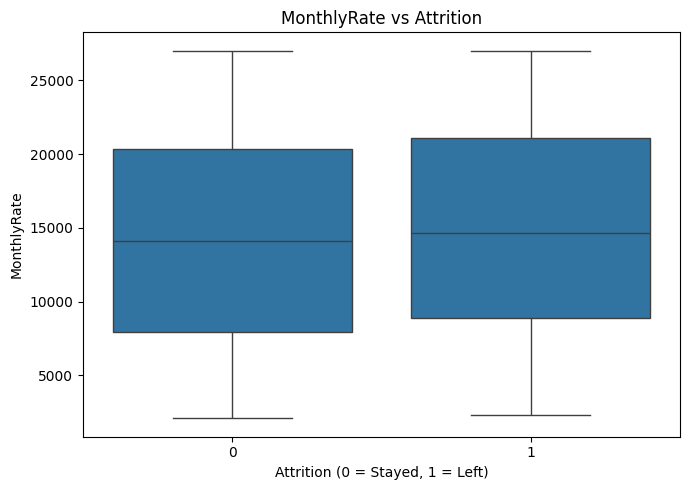

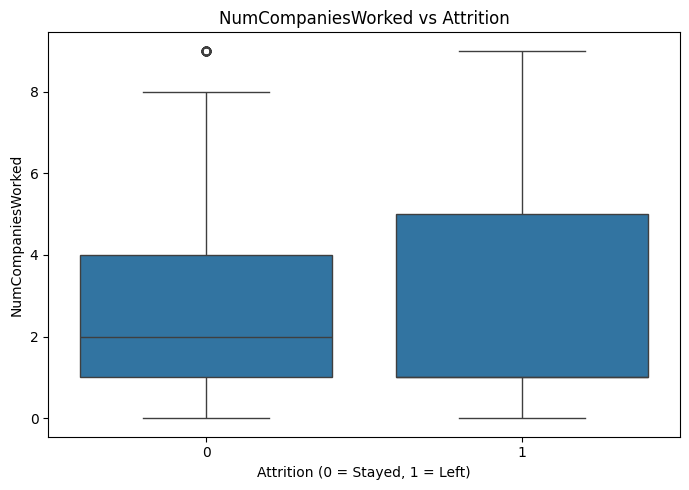

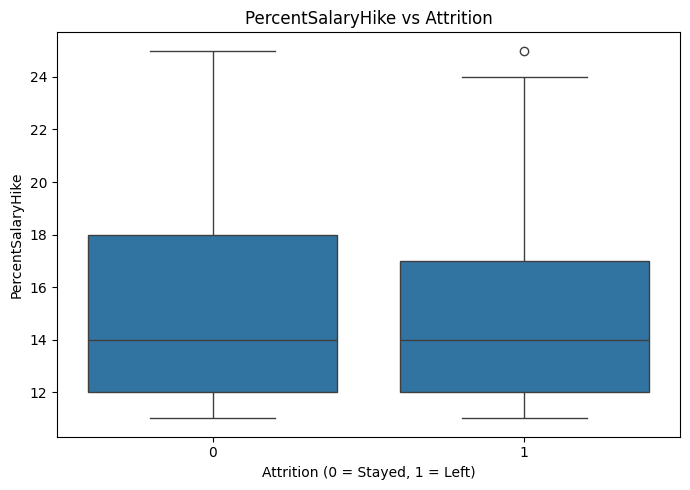

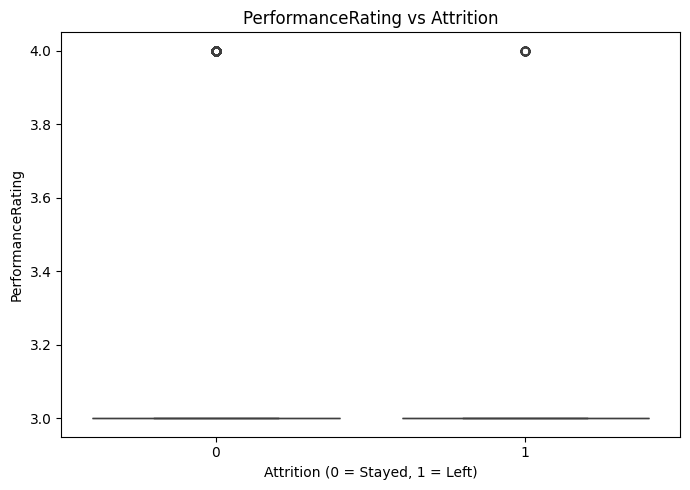

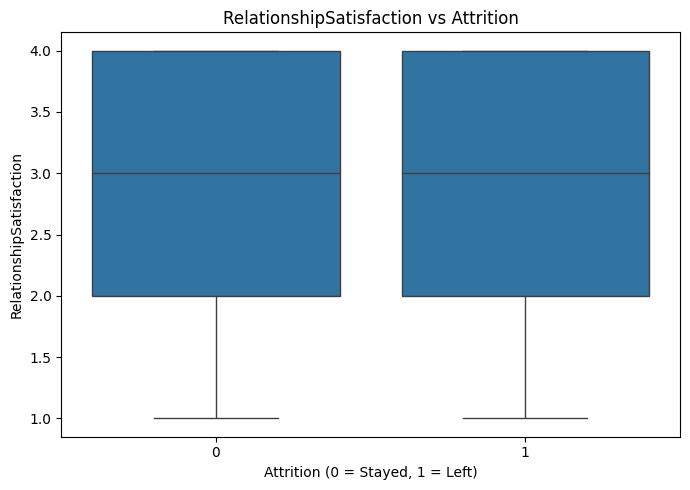

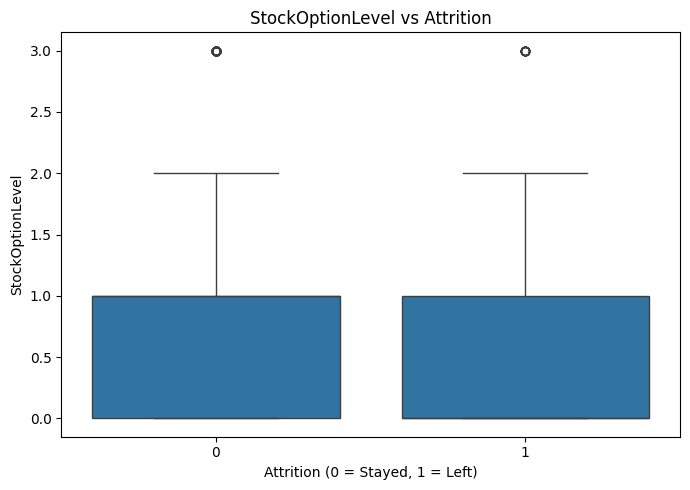

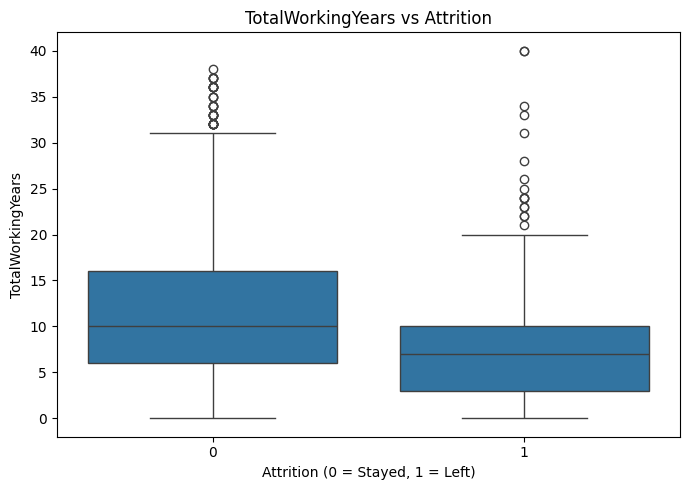

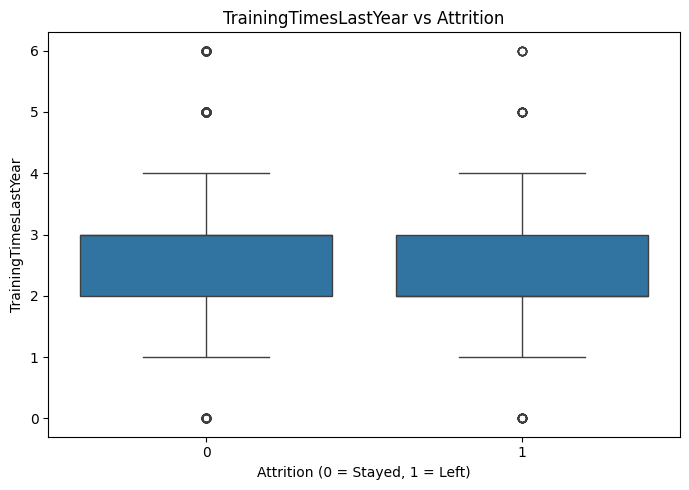

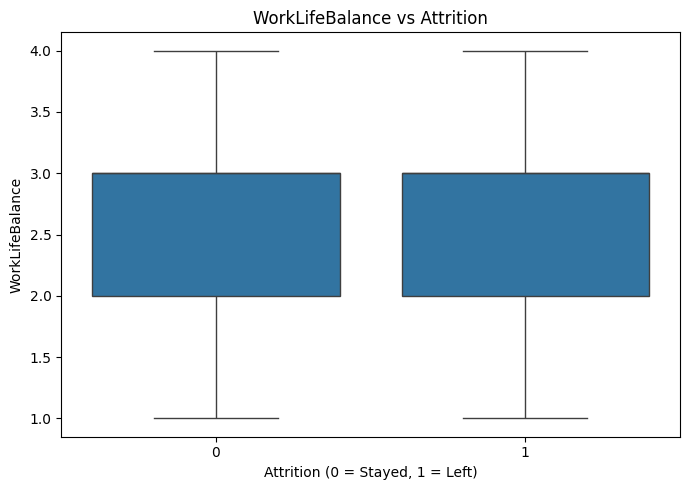

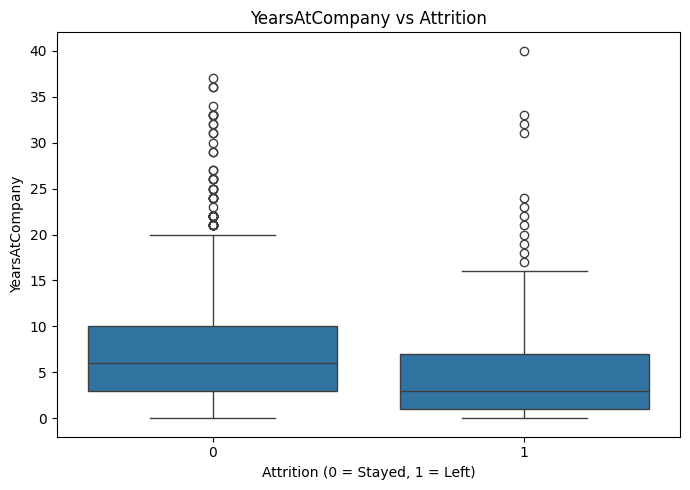

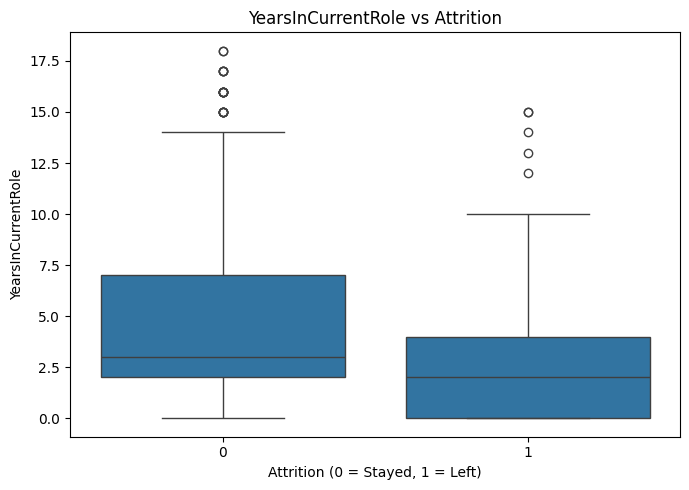

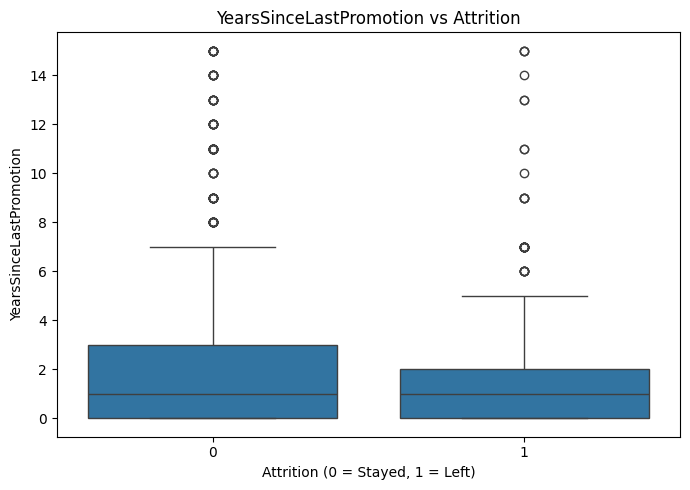

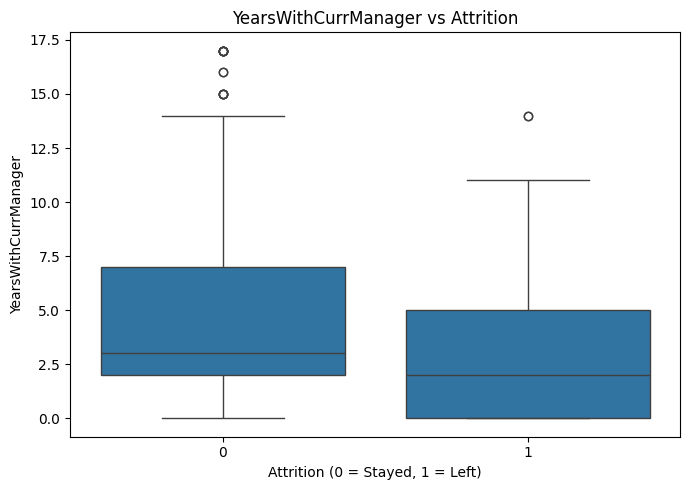

In [19]:
# ============================================================
#  NUMERICAL VARIABLES VS ATTRITION
# ============================================================

numerical_features = [
    col for col in numerical_columns
    if col != "Attrition"
]

for column in numerical_features:

    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df,
        x="Attrition",
        y=column
    )

    plt.title(f"{column} vs Attrition")
    plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
    plt.ylabel(column)

    plt.tight_layout()
    plt.show()

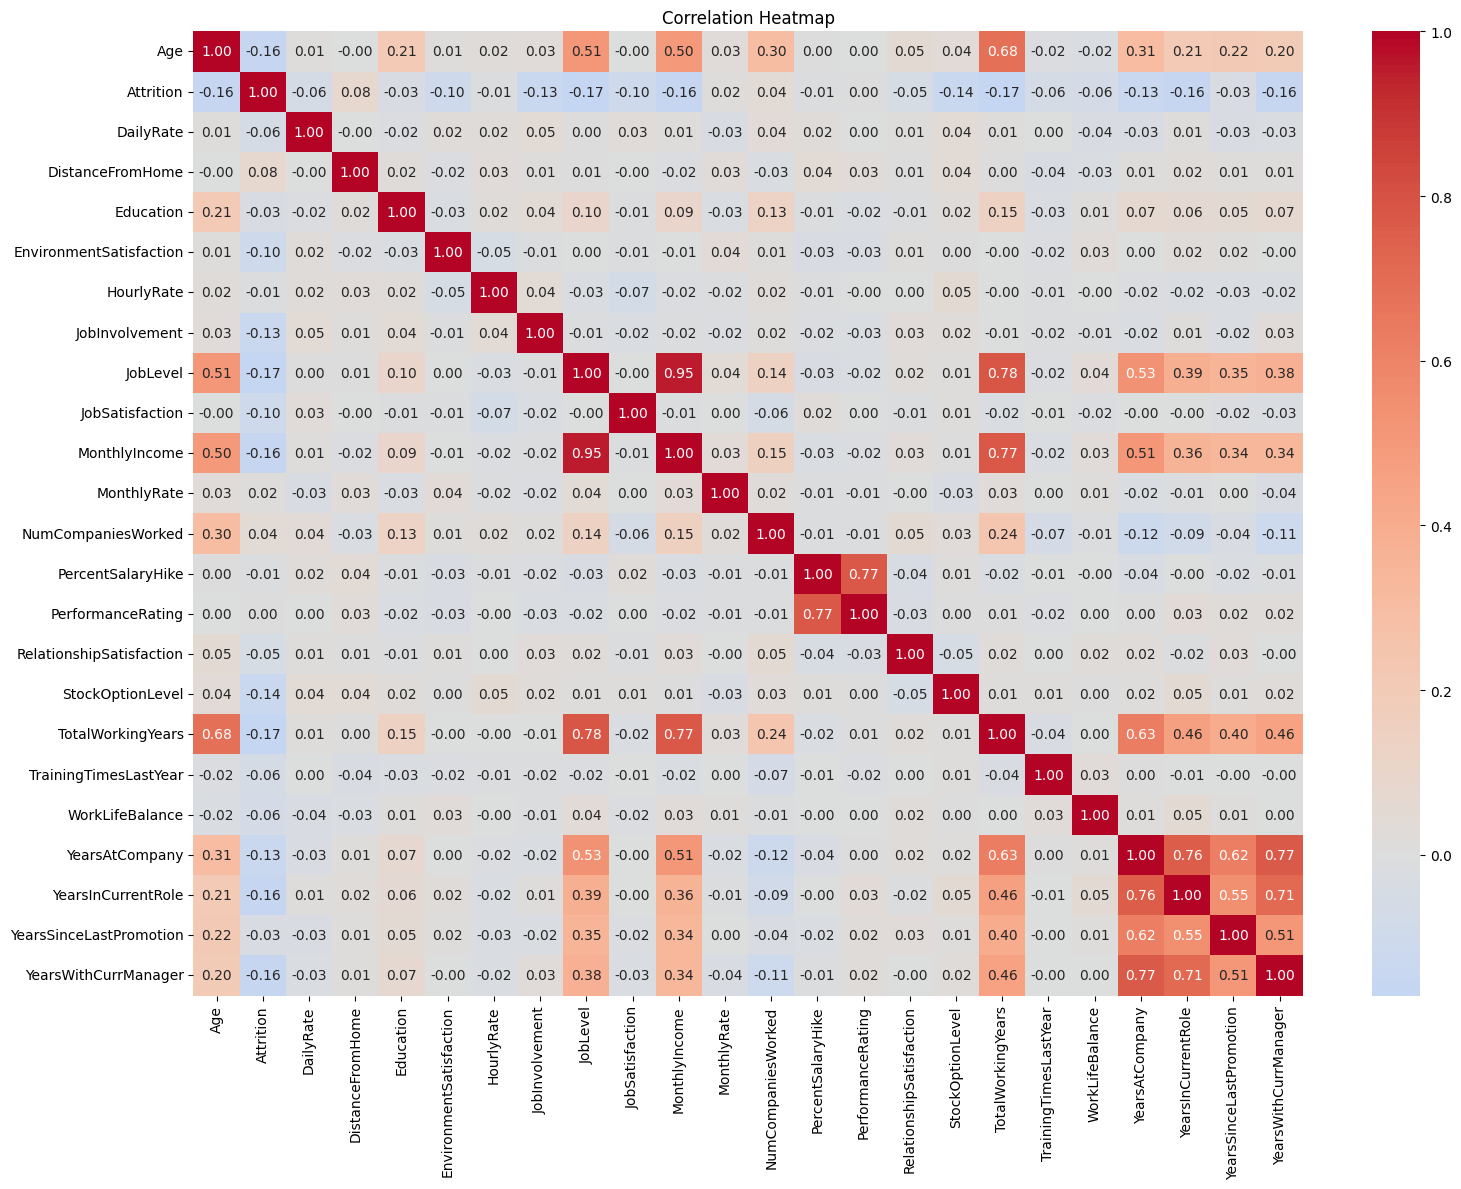

In [20]:
# ============================================================
#  CORRELATION ANALYSIS
# ============================================================

correlation = df[numerical_columns].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# INCOME-TO-EXPERIENCE RATIO
# ============================================================

df["IncomeToExperienceRatio"] = (
    df["MonthlyIncome"] /
    (df["TotalWorkingYears"] + 1)
)

In [22]:
# ============================================================
#  PROMOTION DELAY INDICATOR
# ============================================================

df["PromotionDelay"] = np.where(
    df["YearsSinceLastPromotion"] >= 5,
    1,
    0
)

print(df["PromotionDelay"].value_counts())

PromotionDelay
0    1210
1     260
Name: count, dtype: int64


In [23]:
# ============================================================
#  ENGAGEMENT COMPOSITE SCORE
# ============================================================

df["EngagementScore"] = (
    df["JobInvolvement"] +
    df["JobSatisfaction"] +
    df["EnvironmentSatisfaction"] +
    df["RelationshipSatisfaction"] +
    df["WorkLifeBalance"]
) / 5

df["EngagementScore"].describe()

,EngagementScore
count,1470.000000
mean,2.730748
std,0.428551
min,1.200000
25%,2.400000
50%,2.800000
75%,3.000000
max,4.000000


In [24]:
# ============================================================
#  WORKLOAD STRESS FLAG
# ============================================================

df["WorkloadStress"] = np.where(
    (df["OverTime"] == "Yes") &
    (df["WorkLifeBalance"] <= 2),
    1,
    0
)

print(df["WorkloadStress"].value_counts())

WorkloadStress
0    1344
1     126
Name: count, dtype: int64


In [25]:
# ============================================================
# CHECK ENGINEERED FEATURES
# ============================================================

engineered_features = [
    "IncomeToExperienceRatio",
    "PromotionDelay",
    "EngagementScore",
    "WorkloadStress"
]

df[engineered_features].describe()

,IncomeToExperienceRatio,PromotionDelay,EngagementScore,WorkloadStress
count,1470.000000,1470.000000,1470.000000,1470.000000
mean,587.575385,0.176871,2.730748,0.085714
std,284.650784,0.381689,0.428551,0.280037
min,95.285714,0.000000,1.200000,0.000000
25%,374.232143,0.000000,2.400000,0.000000
50%,549.220648,0.000000,2.800000,0.000000
75%,738.303846,0.000000,3.000000,0.000000
max,1904.000000,1.000000,4.000000,1.000000


In [26]:
# ============================================================
#  PREPARE FEATURES AND TARGET
# ============================================================

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1470, 34)
y shape: (1470,)


In [27]:
# ============================================================
# 16. FEATURE TYPE IDENTIFICATION
# ============================================================

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Numerical Features:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'IncomeToExperienceRatio', 'PromotionDelay', 'EngagementScore', 'WorkloadStress']


In [28]:
# ============================================================
# TRAIN-TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training data: (1176, 34)
Testing data: (294, 34)

Training target distribution:
Attrition
0    0.838435
1    0.161565
Name: proportion, dtype: float64

Testing target distribution:
Attrition
0    0.840136
1    0.159864
Name: proportion, dtype: float64


In [29]:
# ============================================================
#  PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

In [30]:
# ============================================================
# 19. LOGISTIC REGRESSION
# ============================================================

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression completed.")

Logistic Regression completed.


In [31]:
# ============================================================
# RANDOM FOREST
# ============================================================

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest completed.")

Random Forest completed.


In [32]:
# ============================================================
# GRADIENT BOOSTING
# ============================================================

gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting completed.")

Gradient Boosting completed.


In [33]:
# ============================================================
# MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(model_name, y_true, y_pred, y_prob):

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

In [34]:
# ============================================================
#  MODEL COMPARISON
# ============================================================

results = pd.DataFrame([
    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred_lr,
        y_prob_lr
    ),

    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf,
        y_prob_rf
    ),

    evaluate_model(
        "Gradient Boosting",
        y_test,
        y_pred_gb,
        y_prob_gb
    )
])

results = results.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.772109,0.380952,0.680851,0.488550,0.804893
1,Gradient Boosting,0.846939,0.555556,0.212766,0.307692,0.783530
2,Random Forest,0.843537,0.571429,0.085106,0.148148,0.782496


In [35]:
# ============================================================
# CLASSIFICATION REPORTS
# ============================================================

print("LOGISTIC REGRESSION")
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Stayed", "Left"]
    )
)

print("\nRANDOM FOREST")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Stayed", "Left"]
    )
)

print("\nGRADIENT BOOSTING")
print(
    classification_report(
        y_test,
        y_pred_gb,
        target_names=["Stayed", "Left"]
    )
)

LOGISTIC REGRESSION
              precision    recall  f1-score   support

      Stayed       0.93      0.79      0.85       247
        Left       0.38      0.68      0.49        47

    accuracy                           0.77       294
   macro avg       0.65      0.74      0.67       294
weighted avg       0.84      0.77      0.80       294


RANDOM FOREST
              precision    recall  f1-score   support

      Stayed       0.85      0.99      0.91       247
        Left       0.57      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.71      0.54      0.53       294
weighted avg       0.81      0.84      0.79       294


GRADIENT BOOSTING
              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.91       247
        Left       0.56      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.71      0.59      0.61       294
weighted avg       0

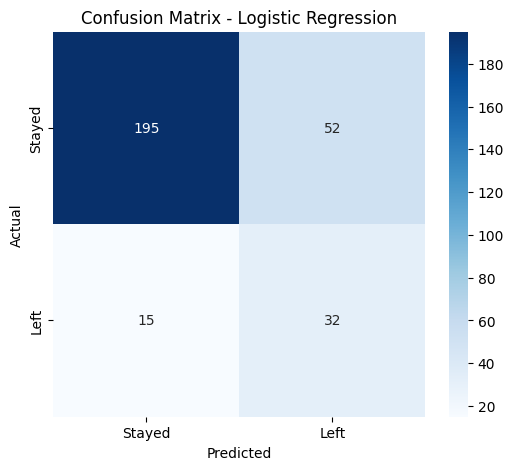

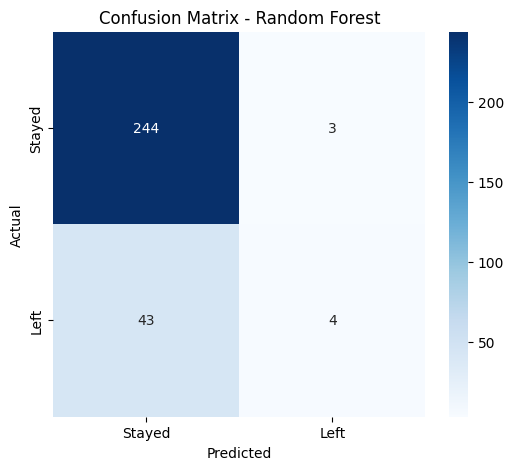

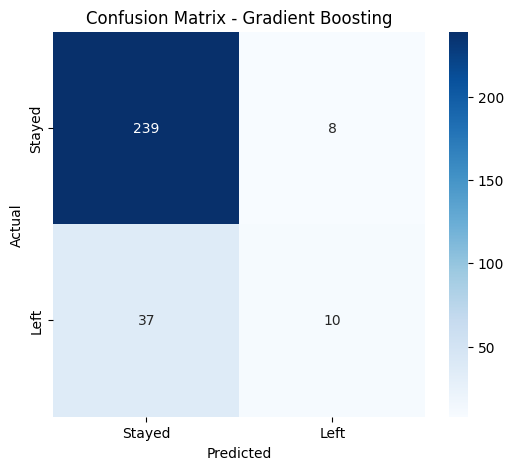

In [36]:
# ============================================================
# 25. CONFUSION MATRICES
# ============================================================

models_predictions = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb
}

for model_name, predictions in models_predictions.items():

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Stayed", "Left"],
        yticklabels=["Stayed", "Left"]
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

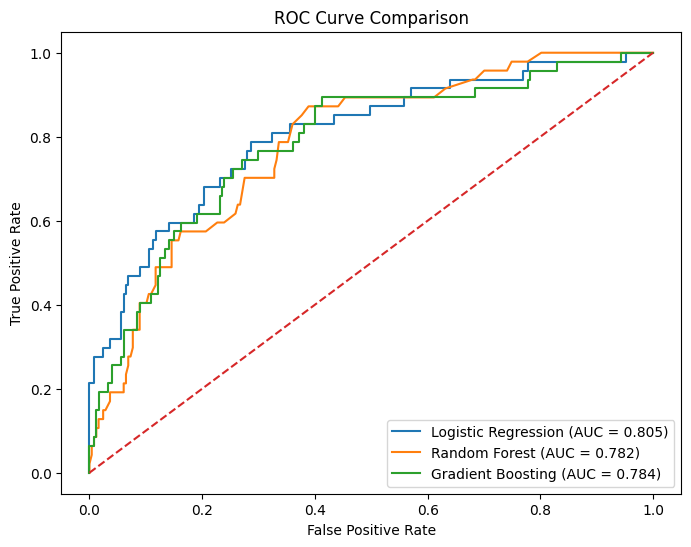

In [37]:
# ============================================================
# 26. ROC CURVE COMPARISON
# ============================================================

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})"
)

plt.plot(
    fpr_gb,
    tpr_gb,
    label=f"Gradient Boosting (AUC = {roc_auc_score(y_test, y_prob_gb):.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

In [38]:
# ============================================================
#  BEST MODEL
# ============================================================

best_model_name = results.loc[
    0,
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [39]:
# ============================================================
# SELECT TRAINED BEST MODEL
# ============================================================

trained_models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

probabilities = {
    "Logistic Regression": y_prob_lr,
    "Random Forest": y_prob_rf,
    "Gradient Boosting": y_prob_gb
}

best_model = trained_models[best_model_name]

best_probabilities = probabilities[best_model_name]


In [40]:
# ============================================================
#  RISK CATEGORY
# ============================================================

def assign_risk(probability):

    if probability < 0.30:
        return "Low Risk"

    elif probability <= 0.60:
        return "Medium Risk"

    else:
        return "High Risk"


risk_categories = [
    assign_risk(prob)
    for prob in best_probabilities
]

risk_results = X_test.copy()

risk_results["Actual_Attrition"] = y_test.values
risk_results["Attrition_Probability"] = best_probabilities
risk_results["Risk_Category"] = risk_categories

risk_results.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,IncomeToExperienceRatio,PromotionDelay,EngagementScore,WorkloadStress,Actual_Attrition,Attrition_Probability,Risk_Category
1061,24,Non-Travel,830,Sales,13,2,Life Sciences,4,Female,78,3,1,Sales Representative,2,Married,2033,7103,1,No,13,3,3,1,1,2,3,1,0,0,0,1016.500000,0,3.0,0,0,0.355992,Medium Risk
891,44,Travel_Rarely,1117,Research & Development,2,1,Life Sciences,1,Female,72,4,1,Research Scientist,4,Married,2011,19982,1,No,13,3,4,1,10,5,3,10,5,7,7,182.818182,1,3.2,0,0,0.023252,Low Risk
456,31,Travel_Rarely,688,Sales,7,3,Life Sciences,3,Male,44,2,3,Manager,4,Divorced,11557,25291,9,No,21,4,3,1,10,3,2,5,4,0,1,1050.636364,0,2.8,0,0,0.484647,Medium Risk
922,44,Travel_Rarely,1199,Research & Development,4,2,Life Sciences,3,Male,92,4,5,Manager,1,Divorced,19190,17477,1,No,14,3,4,2,26,4,2,25,9,14,13,710.740741,1,2.8,0,0,0.026377,Low Risk
69,36,Travel_Rarely,318,Research & Development,9,3,Medical,4,Male,79,2,1,Research Scientist,3,Married,3388,21777,0,Yes,17,3,1,1,2,0,2,1,0,0,0,1129.333333,0,2.4,1,1,0.762184,High Risk


Risk_Category
Low Risk       156
Medium Risk     80
High Risk       58
Name: count, dtype: int64


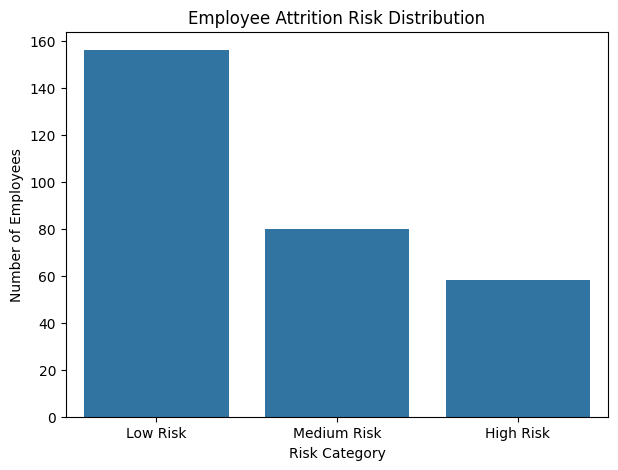

In [41]:
# ==========================================================
#  RISK DISTRIBUTION
# ============================================================

risk_distribution = (
    risk_results["Risk_Category"]
    .value_counts()
)

print(risk_distribution)

plt.figure(figsize=(7, 5))

sns.countplot(
    data=risk_results,
    x="Risk_Category",
    order=["Low Risk", "Medium Risk", "High Risk"]
)

plt.title("Employee Attrition Risk Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Employees")

plt.show()

In [42]:
# ============================================================
# 31. HIGH-RISK EMPLOYEES
# ============================================================

high_risk_count = (
    risk_results["Risk_Category"] == "High Risk"
).sum()

medium_risk_count = (
    risk_results["Risk_Category"] == "Medium Risk"
).sum()

low_risk_count = (
    risk_results["Risk_Category"] == "Low Risk"
).sum()

print("High Risk Employees:", high_risk_count)
print("Medium Risk Employees:", medium_risk_count)
print("Low Risk Employees:", low_risk_count)

High Risk Employees: 58
Medium Risk Employees: 80
Low Risk Employees: 156


In [43]:
# ============================================================
#  DEPARTMENT-LEVEL RISK
# ============================================================

department_risk = (
    risk_results
    .groupby("Department")
    .agg(
        Employee_Count=("Attrition_Probability", "count"),
        Average_Risk=("Attrition_Probability", "mean"),
        High_Risk_Count=(
            "Risk_Category",
            lambda x: (x == "High Risk").sum()
        )
    )
    .reset_index()
)

department_risk["Average_Risk"] *= 100

department_risk

,Department,Employee_Count,Average_Risk,High_Risk_Count
0,Human Resources,15,34.520026,2
1,Research & Development,197,30.190422,31
2,Sales,82,44.574607,25


In [44]:
# ============================================================
# 33. JOB ROLE-LEVEL RISK
# ============================================================

role_risk = (
    risk_results
    .groupby("JobRole")
    .agg(
        Employee_Count=("Attrition_Probability", "count"),
        Average_Risk=("Attrition_Probability", "mean"),
        High_Risk_Count=(
            "Risk_Category",
            lambda x: (x == "High Risk").sum()
        )
    )
    .reset_index()
)

role_risk["Average_Risk"] *= 100

role_risk = role_risk.sort_values(
    "Average_Risk",
    ascending=False
)

role_risk

,JobRole,Employee_Count,Average_Risk,High_Risk_Count
8,Sales Representative,23,68.244695,13
2,Laboratory Technician,44,42.227311,11
7,Sales Executive,53,37.368810,12
1,Human Resources,11,35.973733,2
6,Research Scientist,72,33.958115,16
4,Manufacturing Director,32,26.953172,2
0,Healthcare Representative,23,23.872529,2
3,Manager,19,17.726606,0
5,Research Director,17,7.246131,0


In [45]:
# ============================================================
# 34. FEATURE IMPORTANCE
# ============================================================

if best_model_name in ["Random Forest", "Gradient Boosting"]:

    preprocessor_fitted = best_model.named_steps["preprocessor"]
    classifier = best_model.named_steps["classifier"]

    feature_names = (
        preprocessor_fitted
        .get_feature_names_out()
    )

    importance_values = classifier.feature_importances_

    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance_values
    })

    feature_importance = feature_importance.sort_values(
        "Importance",
        ascending=False
    )

    display(feature_importance.head(20))

    plt.figure(figsize=(10, 8))

    sns.barplot(
        data=feature_importance.head(15),
        x="Importance",
        y="Feature"
    )

    plt.title("Top 15 Feature Importances")
    plt.tight_layout()

    plt.show()

Here best_model is logistic regression . so plot is not visible

In [46]:
# ============================================================
# 35. LOGISTIC REGRESSION COEFFICIENTS
# ============================================================

lr_preprocessor = logistic_model.named_steps["preprocessor"]
lr_classifier = logistic_model.named_steps["classifier"]

lr_feature_names = (
    lr_preprocessor
    .get_feature_names_out()
)

lr_coefficients = lr_classifier.coef_[0]

lr_importance = pd.DataFrame({
    "Feature": lr_feature_names,
    "Coefficient": lr_coefficients,
    "Absolute_Coefficient": np.abs(lr_coefficients)
})

lr_importance = lr_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

display(lr_importance.head(20))

,Feature,Coefficient,Absolute_Coefficient
27,cat__BusinessTravel_Travel_Frequently,1.662867,1.662867
47,cat__OverTime_Yes,1.549789,1.549789
38,cat__JobRole_Laboratory Technician,1.524772,1.524772
44,cat__JobRole_Sales Representative,1.243904,1.243904
41,cat__JobRole_Research Director,-1.108747,1.108747
34,cat__EducationField_Other,-1.052137,1.052137
28,cat__BusinessTravel_Travel_Rarely,0.954207,0.954207
46,cat__MaritalStatus_Single,0.845330,0.845330
37,cat__JobRole_Human Resources,0.622048,0.622048
9,num__MonthlyIncome,-0.576952,0.576952


In [47]:
# ============================================================
# EMPLOYEE ID
# ============================================================

df["EmployeeID"] = range(1, len(df) + 1)

df[["EmployeeID", "Age", "Department", "JobRole", "Attrition"]].head()

,EmployeeID,Age,Department,JobRole,Attrition
0,1,41,Sales,Sales Executive,1
1,2,49,Research & Development,Research Scientist,0
2,3,37,Research & Development,Laboratory Technician,1
3,4,33,Research & Development,Research Scientist,0
4,5,27,Research & Development,Laboratory Technician,0


In [48]:
# ============================================================
#  GENERATE RISK SCORE FOR EVERY EMPLOYEE
# ============================================================

# Remove target and EmployeeID from prediction data
X_all = df.drop(
    columns=["Attrition", "EmployeeID"],
    errors="ignore"
)

# Predict attrition probability
all_probabilities = best_model.predict_proba(X_all)[:, 1]

# Convert probability into percentage
df["Attrition_Probability"] = all_probabilities * 100

In [49]:
# ============================================================
# ASSIGN RISK CATEGORY
# ============================================================

def assign_risk_category(probability):

    if probability < 30:
        return "Low Risk"

    elif probability <= 60:
        return "Medium Risk"

    else:
        return "High Risk"


df["Risk_Category"] = df["Attrition_Probability"].apply(
    assign_risk_category
)

In [50]:
df[
    [
        "EmployeeID",
        "Attrition_Probability",
        "Risk_Category"
    ]
].head(10)

,EmployeeID,Attrition_Probability,Risk_Category
0,1,90.868881,High Risk
1,2,9.998332,Low Risk
2,3,69.463107,High Risk
3,4,30.000995,Medium Risk
4,5,78.651395,High Risk
5,6,20.030909,Low Risk
6,7,44.349045,Medium Risk
7,8,45.332755,Medium Risk
8,9,33.725524,Medium Risk
9,10,22.018028,Low Risk


In [51]:
# ============================================================
#  EMPLOYEE RISK PROFILE
# ============================================================

risk_profile = df[
    [
        "EmployeeID",
        "Age",
        "Department",
        "JobRole",
        "MonthlyIncome",
        "JobSatisfaction",
        "EnvironmentSatisfaction",
        "WorkLifeBalance",
        "OverTime",
        "YearsAtCompany",
        "Attrition_Probability",
        "Risk_Category"
    ]
].copy()

risk_profile["Attrition_Probability"] = (
    risk_profile["Attrition_Probability"].round(2)
)

risk_profile.head(10)

,EmployeeID,Age,Department,JobRole,MonthlyIncome,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance,OverTime,YearsAtCompany,Attrition_Probability,Risk_Category
0,1,41,Sales,Sales Executive,5993,4,2,1,Yes,6,90.87,High Risk
1,2,49,Research & Development,Research Scientist,5130,2,3,3,No,10,10.00,Low Risk
2,3,37,Research & Development,Laboratory Technician,2090,3,4,3,Yes,0,69.46,High Risk
3,4,33,Research & Development,Research Scientist,2909,3,4,3,Yes,8,30.00,Medium Risk
4,5,27,Research & Development,Laboratory Technician,3468,2,1,3,No,2,78.65,High Risk
5,6,32,Research & Development,Laboratory Technician,3068,4,4,2,No,7,20.03,Low Risk
6,7,59,Research & Development,Laboratory Technician,2670,1,3,2,Yes,1,44.35,Medium Risk
7,8,30,Research & Development,Laboratory Technician,2693,3,4,3,No,1,45.33,Medium Risk
8,9,38,Research & Development,Manufacturing Director,9526,3,4,3,No,9,33.73,Medium Risk
9,10,36,Research & Development,Healthcare Representative,5237,3,3,2,No,7,22.02,Low Risk


In [52]:
# ============================================================
#  HIGH-RISK EMPLOYEES
# ============================================================

high_risk_employees = risk_profile[
    risk_profile["Risk_Category"] == "High Risk"
].sort_values(
    by="Attrition_Probability",
    ascending=False
)

print("Number of High-Risk Employees:",
      len(high_risk_employees))

high_risk_employees.head(20)

Number of High-Risk Employees: 329


,EmployeeID,Age,Department,JobRole,MonthlyIncome,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance,OverTime,YearsAtCompany,Attrition_Probability,Risk_Category
463,464,26,Research & Development,Laboratory Technician,2340,4,3,1,Yes,1,99.33,High Risk
457,458,18,Sales,Sales Representative,1878,2,2,3,Yes,0,99.25,High Risk
1060,1061,24,Research & Development,Laboratory Technician,3172,1,2,2,Yes,0,99.04,High Risk
357,358,21,Sales,Sales Representative,2174,2,1,3,Yes,3,98.80,High Risk
127,128,19,Sales,Sales Representative,1675,3,4,2,Yes,0,98.60,High Risk
656,657,32,Research & Development,Laboratory Technician,2795,4,1,1,Yes,1,98.45,High Risk
1057,1058,29,Sales,Sales Executive,5765,2,1,1,No,5,98.30,High Risk
911,912,25,Sales,Sales Representative,1118,4,3,3,Yes,1,98.16,High Risk
1153,1154,18,Sales,Sales Representative,1569,4,2,4,Yes,0,97.99,High Risk
1326,1327,32,Sales,Sales Executive,9907,2,3,2,Yes,2,97.37,High Risk


Risk_Category
Low Risk       760
Medium Risk    381
High Risk      329
Name: count, dtype: int64


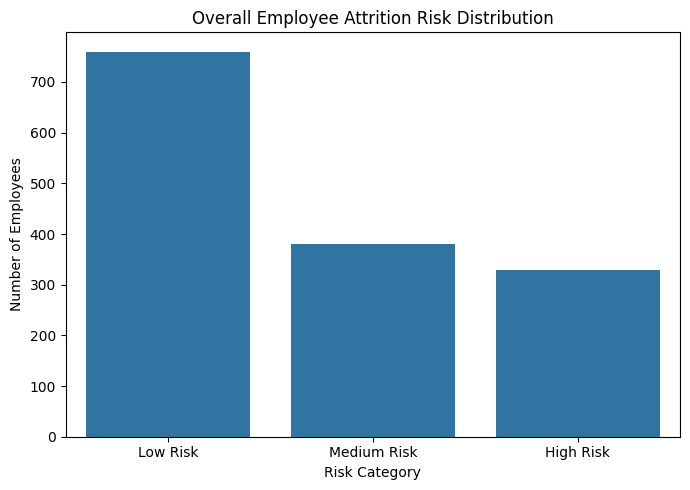

In [53]:
# ============================================================
# 41. OVERALL RISK DISTRIBUTION
# ============================================================

risk_counts = (
    risk_profile["Risk_Category"]
    .value_counts()
    .reindex(
        ["Low Risk", "Medium Risk", "High Risk"],
        fill_value=0
    )
)

print(risk_counts)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=risk_counts.index,
    y=risk_counts.values
)

plt.title("Overall Employee Attrition Risk Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

In [54]:
# ============================================================
#  INDIVIDUAL EMPLOYEE RISK PROFILE
# ============================================================

def get_employee_risk_profile(employee_id):

    employee = risk_profile[
        risk_profile["EmployeeID"] == employee_id
    ]

    if employee.empty:
        print("Employee ID not found.")
        return None

    return employee.T

In [55]:
get_employee_risk_profile(10)

,9
EmployeeID,10
Age,36
Department,Research & Development
JobRole,Healthcare Representative
MonthlyIncome,5237
JobSatisfaction,3
EnvironmentSatisfaction,3
WorkLifeBalance,2
OverTime,No
YearsAtCompany,7


In [56]:
# ============================================================
# 43. KEY CONTRIBUTING FACTORS
# ============================================================

def get_contributing_factors(employee_id):

    employee = df[
        df["EmployeeID"] == employee_id
    ]

    if employee.empty:
        print("Employee ID not found.")
        return []

    employee = employee.iloc[0]

    factors = []

    if employee["OverTime"] == "Yes":
        factors.append("Works overtime")

    if employee["JobSatisfaction"] <= 2:
        factors.append("Low job satisfaction")

    if employee["EnvironmentSatisfaction"] <= 2:
        factors.append("Low environment satisfaction")

    if employee["RelationshipSatisfaction"] <= 2:
        factors.append("Low relationship satisfaction")

    if employee["WorkLifeBalance"] <= 2:
        factors.append("Poor work-life balance")

    if employee["YearsSinceLastPromotion"] >= 5:
        factors.append("Long time since last promotion")

    if employee["YearsInCurrentRole"] >= 7:
        factors.append("Long tenure in current role")

    if employee["YearsWithCurrManager"] >= 7:
        factors.append("Long time with current manager")

    if employee["JobInvolvement"] <= 2:
        factors.append("Low job involvement")

    return factors

In [57]:
factors = get_contributing_factors(5)

if factors:
    for factor in factors:
        print("-", factor)
else:
    print("No major risk indicators identified.")

- Low job satisfaction
- Low environment satisfaction


In [58]:
# ============================================================
# 45. WHAT-IF SCENARIO PREDICTION
# ============================================================

def what_if_prediction(
    employee_id,
    overtime=None,
    job_satisfaction=None,
    environment_satisfaction=None,
    work_life_balance=None,
    monthly_income=None
):

    # Find employee
    employee = df[
        df["EmployeeID"] == employee_id
    ]

    if employee.empty:
        print("Employee ID not found.")
        return None

    # Copy employee data
    scenario = employee.iloc[0].copy()

    # Apply changes only when provided
    if overtime is not None:
        scenario["OverTime"] = overtime

    if job_satisfaction is not None:
        scenario["JobSatisfaction"] = job_satisfaction

    if environment_satisfaction is not None:
        scenario["EnvironmentSatisfaction"] = environment_satisfaction

    if work_life_balance is not None:
        scenario["WorkLifeBalance"] = work_life_balance

    if monthly_income is not None:
        scenario["MonthlyIncome"] = monthly_income

    # Remove columns not used for prediction
    scenario_X = pd.DataFrame(
        [scenario.drop(
            labels=["Attrition", "EmployeeID"],
            errors="ignore"
        )]
    )

    # Predict probability
    probability = best_model.predict_proba(
        scenario_X
    )[0, 1]

    probability_percentage = probability * 100

    # Assign risk
    risk = assign_risk_category(
        probability_percentage
    )

    return {
        "EmployeeID": employee_id,
        "Attrition_Probability": round(
            probability_percentage, 2
        ),
        "Risk_Category": risk
    }

In [59]:
# ============================================================
#CURRENT RISK
# ============================================================

employee_id=10
current_result = what_if_prediction(
    employee_id=employee_id
)

print("Current Scenario:")
print(current_result)

Current Scenario:
{'EmployeeID': 10, 'Attrition_Probability': np.float64(22.02), 'Risk_Category': 'Low Risk'}


In [60]:
# ============================================================
#  WHAT-IF SCENARIO
# ============================================================

what_if_result = what_if_prediction(
    employee_id=employee_id,
    overtime="No",
    job_satisfaction=4,
    environment_satisfaction=4,
    work_life_balance=4
)

print("What-If Scenario:")
print(what_if_result)

What-If Scenario:
{'EmployeeID': 10, 'Attrition_Probability': np.float64(13.13), 'Risk_Category': 'Low Risk'}


In [61]:
# ============================================================
#  CURRENT VS WHAT-IF COMPARISON
# ============================================================

comparison = pd.DataFrame({
    "Scenario": [
        "Current",
        "What-If"
    ],
    "Attrition_Probability": [
        current_result["Attrition_Probability"],
        what_if_result["Attrition_Probability"]
    ],
    "Risk_Category": [
        current_result["Risk_Category"],
        what_if_result["Risk_Category"]
    ]
})

comparison

,Scenario,Attrition_Probability,Risk_Category
0,Current,22.02,Low Risk
1,What-If,13.13,Low Risk


In [62]:
# ============================================================
# RISK CHANGE
# ============================================================

current_probability = (
    current_result["Attrition_Probability"]
)

what_if_probability = (
    what_if_result["Attrition_Probability"]
)

change = (
    what_if_probability -
    current_probability
)

print(
    f"Current Risk: {current_probability:.2f}%"
)

print(
    f"What-If Risk: {what_if_probability:.2f}%"
)

print(
    f"Change in Risk: {change:+.2f} percentage points"
)

Current Risk: 22.02%
What-If Risk: 13.13%
Change in Risk: -8.89 percentage points


In [63]:
# ============================================================
#  SAVE MODEL RESULTS
# ============================================================

results.to_csv(
    "model_performance.csv",
    index=False
)

risk_results.to_csv(
    "employee_risk_scores.csv",
    index=False
)

department_risk.to_csv(
    "department_risk.csv",
    index=False
)

role_risk.to_csv(
    "role_risk.csv",
    index=False
)
risk_profile.to_csv(
    "employee_risk_scores.csv",
    index=False
)

print("Result files saved successfully.")

Result files saved successfully.


In [64]:
%%writefile app.py

import streamlit as st
import pandas as pd

# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Palo Alto Networks - Employee Attrition",
    page_icon="📊",
    layout="wide"
)

# ============================================================
# LOAD DATA
# ============================================================

file_path = "/content/drive/MyDrive/Palo Alto Networks.csv"

df = pd.read_csv(file_path)

# ============================================================
# TITLE
# ============================================================

st.title("📊 Palo Alto Networks Employee Attrition Risk Dashboard")

st.write(
    "Machine Learning-Based Employee Attrition Prediction "
    "and Risk Scoring System"
)

# ============================================================
# BASIC DATASET INFORMATION
# ============================================================

st.subheader("Dataset Overview")

col1, col2, col3 = st.columns(3)

col1.metric(
    "Total Employees",
    len(df)
)

col2.metric(
    "Total Features",
    len(df.columns)
)

col3.metric(
    "Employees Who Left",
    int(df["Attrition"].sum())
)

# ============================================================
# DATA PREVIEW
# ============================================================

st.subheader("Employee Dataset")

st.dataframe(
    df.head(20),
    use_container_width=True
)


Writing app.py


In [65]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 107.3 MB/s eta 0:00:00


In [66]:
!streamlit run app.py &>/content/streamlit.log &

In [70]:
from google.colab import output

print(output.eval_js("google.colab.kernel.proxyPort(8501)"))

https://8501-m-s-kkb-use1d0-hjha78z43c8w-d.us-east1-0.prod.colab.dev


In [71]:
print(open("/content/streamlit.log").read())



2026-08-30 06:13:39.630 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.237.190.95:8501

2026-08-30 06:14:27.970 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-use1d0-hjha78z43c8w-d.us-east1-0.prod.colab.dev, host=m-s-kkb-use1d0-hjha78z43c8w.us-east1-d.c.codatalab-user-runtimes.internal:8007
2026-08-30 06:14:29.209 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-use1d0-hjha78z43c8w-d.us-east1-0.prod.colab.dev, host=m-s-kkb-use1d0-hjha78z43c8w.us-east1-d.c.codatalab-user-runtimes.internal:8007
2026-08-30 06:14:31.794 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-use1d0-hjha78z43c8w-d.us-east1-0.prod.colab.dev, host=m-s-kkb-use1d0-hjha78z43c8w.us-east1-d.c.codatalab-user-runtimes.internal:8007
2

In [74]:
!ps aux | grep streamlit

root       10929  0.6  0.5 1217052 76820 ?       Sl   06:13   0:10 /usr/bin/python3 /usr/local/bin/streamlit run app.py
root       18280  0.0  0.0   7372  3340 ?        S    06:43   0:00 /bin/bash -c ps aux | grep streamlit
root       18282  0.0  0.0   6480  2560 ?        S    06:43   0:00 grep streamlit


In [151]:
%%writefile app.py

# ============================================================
# PALO ALTO NETWORKS
# EMPLOYEE ATTRITION RISK DASHBOARD
# ============================================================

import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")


# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Employee Attrition Risk Dashboard",
    page_icon="📊",
    layout="wide"
)


# ============================================================
# LOAD DATA
# ============================================================

@st.cache_data
def load_data():

    file_path = (
        Path(__file__).parent /
        "Palo Alto Networks.csv"
    )

    if not file_path.exists():

        st.error(
            "Palo Alto Networks.csv was not found. "
            "Please upload it to the same GitHub repository "
            "as app.py."
        )

        st.stop()

    data = pd.read_csv(file_path)

    return data


df = load_data()


# ============================================================
# REQUIRED COLUMNS
# ============================================================

required_columns = [
    "Attrition",
    "Department",
    "JobRole",
    "MonthlyIncome",
    "TotalWorkingYears",
    "YearsSinceLastPromotion",
    "JobInvolvement",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "RelationshipSatisfaction",
    "WorkLifeBalance",
    "OverTime"
]


missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]


if missing_columns:

    st.error(
        "The following required columns are missing:"
    )

    st.write(missing_columns)

    st.stop()


# ============================================================
# FEATURE ENGINEERING
# ============================================================

df["IncomeToExperienceRatio"] = (
    df["MonthlyIncome"] /
    (df["TotalWorkingYears"] + 1)
)


df["PromotionDelay"] = np.where(
    df["YearsSinceLastPromotion"] >= 5,
    1,
    0
)


df["EngagementScore"] = (
    df["JobInvolvement"]
    + df["JobSatisfaction"]
    + df["EnvironmentSatisfaction"]
    + df["RelationshipSatisfaction"]
    + df["WorkLifeBalance"]
) / 5


df["WorkloadStress"] = np.where(
    (df["OverTime"] == "Yes")
    &
    (df["WorkLifeBalance"] <= 2),
    1,
    0
)


# ============================================================
# EMPLOYEE ID
# ============================================================

df["EmployeeID"] = range(
    1,
    len(df) + 1
)


# ============================================================
# CONVERT TARGET TO 0 / 1
# ============================================================

if df["Attrition"].dtype == "object":

    attrition_values = (
        df["Attrition"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    df["Attrition"] = attrition_values.map({
        "yes": 1,
        "no": 0,
        "1": 1,
        "0": 0
    })

else:

    df["Attrition"] = pd.to_numeric(
        df["Attrition"],
        errors="coerce"
    )


df = df.dropna(
    subset=["Attrition"]
).copy()


df["Attrition"] = (
    df["Attrition"]
    .astype(int)
)


# ============================================================
# FEATURES AND TARGET
# ============================================================

X = df.drop(
    columns=[
        "Attrition",
        "EmployeeID"
    ]
)


y = df["Attrition"]


# ============================================================
# FEATURE TYPES
# ============================================================

categorical_features = (
    X.select_dtypes(
        include=["object", "category"]
    )
    .columns
    .tolist()
)


numerical_features = (
    X.select_dtypes(
        include=[np.number]
    )
    .columns
    .tolist()
)


# ============================================================
# PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(

    transformers=[

        (
            "numerical",

            StandardScaler(),

            numerical_features
        ),

        (
            "categorical",

            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),

            categorical_features
        )
    ]
)


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = (
    train_test_split(

        X,

        y,

        test_size=0.20,

        random_state=42,

        stratify=y
    )
)


# ============================================================
# CREATE MODELS
# ============================================================

def create_models():

    models = {

        "Logistic Regression":

            Pipeline(
                steps=[

                    (
                        "preprocessor",
                        preprocessor
                    ),

                    (
                        "classifier",

                        LogisticRegression(
                            class_weight="balanced",
                            max_iter=1000,
                            random_state=42
                        )
                    )
                ]
            ),


        "Random Forest":

            Pipeline(
                steps=[

                    (
                        "preprocessor",
                        preprocessor
                    ),

                    (
                        "classifier",

                        RandomForestClassifier(
                            n_estimators=300,
                            class_weight="balanced",
                            random_state=42,
                            n_jobs=-1
                        )
                    )
                ]
            ),


        "Gradient Boosting":

            Pipeline(
                steps=[

                    (
                        "preprocessor",
                        preprocessor
                    ),

                    (
                        "classifier",

                        GradientBoostingClassifier(
                            n_estimators=200,
                            learning_rate=0.05,
                            max_depth=3,
                            random_state=42
                        )
                    )
                ]
            )
    }

    return models


# ============================================================
# TRAIN AND EVALUATE MODELS
# ============================================================

@st.cache_resource
def train_models(
    X_train,
    y_train,
    X_test,
    y_test
):

    models = create_models()

    results = []


    for name, model in models.items():

        model.fit(
            X_train,
            y_train
        )


        predictions = model.predict(
            X_test
        )


        probabilities = (
            model
            .predict_proba(X_test)[:, 1]
        )


        results.append({

            "Model": name,

            "Accuracy":
                accuracy_score(
                    y_test,
                    predictions
                ),

            "Precision":
                precision_score(
                    y_test,
                    predictions,
                    zero_division=0
                ),

            "Recall":
                recall_score(
                    y_test,
                    predictions,
                    zero_division=0
                ),

            "F1-Score":
                f1_score(
                    y_test,
                    predictions,
                    zero_division=0
                ),

            "ROC-AUC":
                roc_auc_score(
                    y_test,
                    probabilities
                )
        })


    results_df = pd.DataFrame(
        results
    )


    best_model_name = (
        results_df
        .loc[
            results_df["ROC-AUC"].idxmax(),
            "Model"
        ]
    )


    best_model = models[
        best_model_name
    ]


    return (
        models,
        results_df,
        best_model_name,
        best_model
    )


(
    models,
    model_results,
    best_model_name,
    best_model
) = train_models(
    X_train,
    y_train,
    X_test,
    y_test
)


# ============================================================
# GENERATE ATTRITION PROBABILITY
# ============================================================

X_all = df.drop(
    columns=[
        "Attrition",
        "EmployeeID"
    ]
)


df["Attrition_Probability"] = (
    best_model
    .predict_proba(X_all)[:, 1]
    * 100
)


# ============================================================
# RISK CATEGORY FUNCTION
# ============================================================

def get_risk_category(
    probability,
    threshold
):

    if probability < 30:

        return "Low Risk"

    elif probability < threshold:

        return "Medium Risk"

    else:

        return "High Risk"


# ============================================================
# TITLE
# ============================================================

st.title(
    "📊 Palo Alto Networks Employee Attrition Risk Dashboard"
)

st.write(
    "Machine Learning-Based Employee Attrition "
    "Prediction and Risk Scoring System"
)


# ============================================================
# SIDEBAR
# ============================================================

st.sidebar.header(
    "🎛️ Dashboard Filters"
)


# ------------------------------------------------------------
# DEPARTMENT
# ------------------------------------------------------------

department_options = (
    ["All"]
    +
    sorted(
        df["Department"]
        .dropna()
        .unique()
        .tolist()
    )
)


selected_department = (
    st.sidebar.selectbox(
        "🏢 Department",
        department_options
    )
)


# ------------------------------------------------------------
# JOB ROLE
# ------------------------------------------------------------

role_options = (
    ["All"]
    +
    sorted(
        df["JobRole"]
        .dropna()
        .unique()
        .tolist()
    )
)


selected_role = (
    st.sidebar.selectbox(
        "💼 Job Role",
        role_options
    )
)


# ------------------------------------------------------------
# RISK THRESHOLD
# ------------------------------------------------------------

risk_threshold = (
    st.sidebar.slider(
        "⚠️ High-Risk Threshold (%)",
        min_value=30,
        max_value=90,
        value=60,
        step=5
    )
)


# ============================================================
# FILTER DATA
# ============================================================

filtered_df = df.copy()


if selected_department != "All":

    filtered_df = filtered_df[
        filtered_df["Department"]
        == selected_department
    ]


if selected_role != "All":

    filtered_df = filtered_df[
        filtered_df["JobRole"]
        == selected_role
    ]


# ============================================================
# EMPLOYEE ID SELECTOR
# ============================================================

employee_ids = (
    filtered_df["EmployeeID"]
    .sort_values()
    .tolist()
)


if employee_ids:

    selected_employee = (
        st.sidebar.selectbox(
            "👤 Employee ID",
            employee_ids
        )
    )

else:

    selected_employee = None

    st.sidebar.warning(
        "No employees match the selected filters."
    )


# ------------------------------------------------------------
# SIDEBAR SUMMARY
# ------------------------------------------------------------

st.sidebar.divider()

st.sidebar.subheader(
    "📌 Current Selection"
)


st.sidebar.write(
    f"**Department:** {selected_department}"
)


st.sidebar.write(
    f"**Job Role:** {selected_role}"
)


st.sidebar.write(
    f"**Risk Threshold:** {risk_threshold}%"
)


if selected_employee is not None:

    st.sidebar.write(
        f"**Employee ID:** {selected_employee}"
    )


# ============================================================
# 1. ATTRITION RISK DASHBOARD
# ============================================================

st.header(
    "1. Attrition Risk Dashboard"
)


col1, col2, col3, col4 = (
    st.columns(4)
)


total_employees = len(
    filtered_df
)


high_risk = (
    filtered_df[
        "Attrition_Probability"
    ]
    >= risk_threshold
).sum()


medium_risk = (

    (
        filtered_df[
            "Attrition_Probability"
        ] >= 30
    )

    &

    (
        filtered_df[
            "Attrition_Probability"
        ] < risk_threshold
    )

).sum()


low_risk = (
    filtered_df[
        "Attrition_Probability"
    ] < 30
).sum()


col1.metric(
    "Total Employees",
    int(total_employees)
)


col2.metric(
    "High Risk",
    int(high_risk)
)


col3.metric(
    "Medium Risk",
    int(medium_risk)
)


col4.metric(
    "Low Risk",
    int(low_risk)
)


# ============================================================
# OVERALL RISK DISTRIBUTION
# ============================================================

st.subheader(
    "Overall Risk Distribution"
)


risk_distribution = pd.DataFrame({

    "Risk Category": [
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ],

    "Employees": [
        low_risk,
        medium_risk,
        high_risk
    ]
})


fig, ax = plt.subplots(
    figsize=(8, 5)
)


bars = ax.bar(

    risk_distribution[
        "Risk Category"
    ],

    risk_distribution[
        "Employees"
    ],

    color=[
        "green",
        "orange",
        "red"
    ]
)


ax.set_title(
    "Overall Risk Distribution",
    fontsize=16,
    fontweight="bold"
)


ax.set_xlabel(
    "Risk Category"
)


ax.set_ylabel(
    "Number of Employees"
)


ax.bar_label(

    bars,

    labels=[
        str(int(value))
        for value in
        risk_distribution[
            "Employees"
        ]
    ],

    padding=5,

    fontsize=12,

    fontweight="bold"
)


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)


max_value = max(
    risk_distribution[
        "Employees"
    ]
)


ax.set_ylim(
    0,
    max_value * 1.15
)


plt.tight_layout()


st.pyplot(
    fig,
    use_container_width=True
)


plt.close(fig)


# ============================================================
# HIGH-RISK EMPLOYEES
# ============================================================

st.subheader(
    "High-Risk Employees"
)


high_risk_table = (
    filtered_df[
        filtered_df[
            "Attrition_Probability"
        ] >= risk_threshold
    ]
    [
        [
            "EmployeeID",
            "Age",
            "Department",
            "JobRole",
            "MonthlyIncome",
            "OverTime",
            "JobSatisfaction",
            "WorkLifeBalance",
            "Attrition_Probability"
        ]
    ]
    .copy()
)


high_risk_table[
    "Risk_Category"
] = (
    high_risk_table[
        "Attrition_Probability"
    ]
    .apply(
        lambda x:
        get_risk_category(
            x,
            risk_threshold
        )
    )
)


high_risk_table[
    "Attrition_Probability"
] = (
    high_risk_table[
        "Attrition_Probability"
    ].round(2)
)


high_risk_table = (
    high_risk_table
    .sort_values(
        "Attrition_Probability",
        ascending=False
    )
)


st.dataframe(
    high_risk_table,
    use_container_width=True,
    hide_index=True
)


# ============================================================
# 2. INDIVIDUAL EMPLOYEE RISK PROFILE
# ============================================================

st.header(
    "2. Individual Employee Risk Profile"
)


if selected_employee is not None:

    employee = df[
        df["EmployeeID"]
        == selected_employee
    ].iloc[0]


    employee_risk_category = (
        get_risk_category(
            employee[
                "Attrition_Probability"
            ],
            risk_threshold
        )
    )


    profile_col1, profile_col2, profile_col3 = (
        st.columns(3)
    )


    profile_col1.metric(
        "Employee ID",
        int(
            employee["EmployeeID"]
        )
    )


    profile_col2.metric(
        "Attrition Probability",
        f"{employee['Attrition_Probability']:.2f}%"
    )


    profile_col3.metric(
        "Risk Category",
        employee_risk_category
    )


    st.subheader(
        "Employee Details"
    )


    details = pd.DataFrame({

        "Attribute": [

            "Age",
            "Department",
            "Job Role",
            "Monthly Income",
            "Job Satisfaction",
            "Environment Satisfaction",
            "Relationship Satisfaction",
            "Work-Life Balance",
            "Overtime",
            "Years at Company",
            "Years in Current Role",
            "Years Since Last Promotion"
        ],


        "Value": [

            employee["Age"],
            employee["Department"],
            employee["JobRole"],
            employee["MonthlyIncome"],
            employee["JobSatisfaction"],
            employee["EnvironmentSatisfaction"],
            employee["RelationshipSatisfaction"],
            employee["WorkLifeBalance"],
            employee["OverTime"],
            employee["YearsAtCompany"],
            employee["YearsInCurrentRole"],
            employee["YearsSinceLastPromotion"]
        ]
    })


    st.dataframe(
        details,
        use_container_width=True,
        hide_index=True
    )


# ============================================================
# 3. AGGREGATED RISK BY DEPARTMENT & JOB ROLE
# ============================================================

st.header(
    "3. Aggregated Risk by Department & Job Role"
)


aggregated_risk = (
    filtered_df
    .groupby(
        [
            "Department",
            "JobRole"
        ]
    )[
        "Attrition_Probability"
    ]
    .mean()
    .reset_index()
)


aggregated_risk[
    "Attrition_Probability"
] = (
    aggregated_risk[
        "Attrition_Probability"
    ].round(2)
)


aggregated_risk = (
    aggregated_risk
    .sort_values(
        "Attrition_Probability",
        ascending=False
    )
)


st.subheader(
    "Average Attrition Probability"
)


st.dataframe(
    aggregated_risk,
    use_container_width=True,
    hide_index=True
)


# ------------------------------------------------------------
# BAR CHART
# ------------------------------------------------------------

if len(aggregated_risk) > 0:

    aggregated_risk[
        "Department & Role"
    ] = (

        aggregated_risk[
            "Department"
        ].astype(str)

        + " - "

        + aggregated_risk[
            "JobRole"
        ].astype(str)
    )


    chart_data = (
        aggregated_risk
        .sort_values(
            "Attrition_Probability",
            ascending=True
        )
    )


    fig, ax = plt.subplots(
        figsize=(12, 8)
    )


    bars = ax.barh(

        chart_data[
            "Department & Role"
        ],

        chart_data[
            "Attrition_Probability"
        ]
    )


    ax.set_title(
        "Average Attrition Probability "
        "by Department & Job Role",

        fontsize=16,

        fontweight="bold"
    )


    ax.set_xlabel(
        "Average Attrition Probability (%)"
    )


    ax.set_ylabel(
        "Department & Job Role"
    )


    ax.bar_label(

        bars,

        labels=[
            f"{value:.1f}%"
            for value in
            chart_data[
                "Attrition_Probability"
            ]
        ],

        padding=4,

        fontsize=9
    )


    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.3
    )


    plt.tight_layout()


    st.pyplot(
        fig,
        use_container_width=True
    )


    plt.close(fig)


# ============================================================
# 4. MODEL PERFORMANCE
# ============================================================

st.header(
    "4. Model Performance"
)


display_results = (
    model_results.copy()
)


for column in [

    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"

]:

    display_results[
        column
    ] = (

        display_results[
            column
        ]

        * 100

    ).round(2)


st.dataframe(
    display_results,
    use_container_width=True,
    hide_index=True
)


st.success(
    f"Selected Model: {best_model_name}"
)


# ============================================================
# 5. MODEL EXPLAINABILITY
# ============================================================

st.header(
    "5. Model Explainability"
)


st.subheader(
    f"Top 15 Features Based on Selected Model: "
    f"{best_model_name}"
)


# ------------------------------------------------------------
# SELECTED MODEL COMPONENTS
# ------------------------------------------------------------

selected_preprocessor = (
    best_model
    .named_steps[
        "preprocessor"
    ]
)


selected_classifier = (
    best_model
    .named_steps[
        "classifier"
    ]
)


feature_names = (
    selected_preprocessor
    .get_feature_names_out()
)


# ------------------------------------------------------------
# FEATURE IMPORTANCE
# ------------------------------------------------------------

if best_model_name == "Logistic Regression":

    importance_values = (
        selected_classifier
        .coef_[0]
    )

else:

    importance_values = (
        selected_classifier
        .feature_importances_
    )


feature_importance = pd.DataFrame({

    "Feature":
        feature_names,

    "Importance":
        importance_values
})


feature_importance[
    "Absolute Importance"
] = (
    feature_importance[
        "Importance"
    ].abs()
)


# ------------------------------------------------------------
# TOP 15
# ------------------------------------------------------------

top_features = (
    feature_importance
    .sort_values(
        "Absolute Importance",
        ascending=False
    )
    .head(15)
    .sort_values(
        "Absolute Importance",
        ascending=True
    )
)


# ------------------------------------------------------------
# CLEAN FEATURE NAMES
# ------------------------------------------------------------

top_features["Feature"] = (
    top_features["Feature"]
    .str.replace(
        "numerical__",
        "",
        regex=False
    )
    .str.replace(
        "categorical__",
        "",
        regex=False
    )
)


# ------------------------------------------------------------
# FEATURE IMPORTANCE TABLE
# ------------------------------------------------------------

display_features = (
    top_features[
        [
            "Feature",
            "Importance"
        ]
    ]
    .copy()
)


display_features[
    "Importance"
] = (
    display_features[
        "Importance"
    ].round(3)
)


st.dataframe(
    display_features,
    use_container_width=True,
    hide_index=True
)


# ------------------------------------------------------------
# FEATURE IMPORTANCE CHART
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 7)
)


bars = ax.barh(

    top_features[
        "Feature"
    ],

    top_features[
        "Absolute Importance"
    ]
)


ax.set_title(
    f"Top 15 Features Based on {best_model_name}",
    fontsize=16,
    fontweight="bold"
)


ax.set_xlabel(
    "Feature Importance"
)


ax.set_ylabel(
    "Features"
)


ax.bar_label(
    bars,
    fmt="%.3f",
    padding=4,
    fontsize=9
)


ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)


plt.tight_layout()


st.pyplot(
    fig,
    use_container_width=True
)


plt.close(fig)


st.info(
    "Higher importance indicates a stronger influence "
    "on the model's attrition prediction."
)


# ============================================================
# WHAT-IF SCENARIO EXPLORATION
# ============================================================

st.subheader(
    "What-If Scenario Exploration"
)


st.write(
    "Modify selected employee factors to explore "
    "how the predicted attrition probability changes."
)


if selected_employee is not None:

    # --------------------------------------------------------
    # ORIGINAL EMPLOYEE
    # --------------------------------------------------------

    employee = df[
        df["EmployeeID"]
        == selected_employee
    ].iloc[0]


    # --------------------------------------------------------
    # WHAT-IF CONTROLS
    # --------------------------------------------------------

    col1, col2, col3 = (
        st.columns(3)
    )


    with col1:

        what_if_overtime = st.selectbox(

            "Overtime",

            ["No", "Yes"],

            index=(

                0

                if employee[
                    "OverTime"
                ] == "No"

                else 1
            ),

            key="what_if_overtime"
        )


    with col2:

        what_if_job_satisfaction = (
            st.slider(

                "Job Satisfaction",

                min_value=1,

                max_value=4,

                value=int(
                    employee[
                        "JobSatisfaction"
                    ]
                ),

                key="what_if_job_satisfaction"
            )
        )


    with col3:

        what_if_worklife = (
            st.slider(

                "Work-Life Balance",

                min_value=1,

                max_value=4,

                value=int(
                    employee[
                        "WorkLifeBalance"
                    ]
                ),

                key="what_if_worklife"
            )
        )


    # --------------------------------------------------------
    # CREATE SCENARIO
    # --------------------------------------------------------

    what_if_employee = (
        employee.copy()
    )


    what_if_employee[
        "OverTime"
    ] = what_if_overtime


    what_if_employee[
        "JobSatisfaction"
    ] = what_if_job_satisfaction


    what_if_employee[
        "WorkLifeBalance"
    ] = what_if_worklife


    # --------------------------------------------------------
    # RECALCULATE ENGINEERED FEATURES
    # --------------------------------------------------------

    what_if_employee[
        "IncomeToExperienceRatio"
    ] = (

        what_if_employee[
            "MonthlyIncome"
        ]

        /

        (
            what_if_employee[
                "TotalWorkingYears"
            ] + 1
        )
    )


    what_if_employee[
        "PromotionDelay"
    ] = np.where(

        what_if_employee[
            "YearsSinceLastPromotion"
        ] >= 5,

        1,

        0
    )


    what_if_employee[
        "EngagementScore"
    ] = (

        what_if_employee[
            "JobInvolvement"
        ]

        +

        what_if_employee[
            "JobSatisfaction"
        ]

        +

        what_if_employee[
            "EnvironmentSatisfaction"
        ]

        +

        what_if_employee[
            "RelationshipSatisfaction"
        ]

        +

        what_if_employee[
            "WorkLifeBalance"
        ]

    ) / 5


    what_if_employee[
        "WorkloadStress"
    ] = np.where(

        (
            what_if_employee[
                "OverTime"
            ] == "Yes"
        )

        &

        (
            what_if_employee[
                "WorkLifeBalance"
            ] <= 2
        ),

        1,

        0
    )


    # --------------------------------------------------------
    # PREPARE MODEL INPUT
    # --------------------------------------------------------

    what_if_input = pd.DataFrame(
        [what_if_employee]
    )


    what_if_input = (
        what_if_input
        .drop(
            columns=[
                "Attrition",
                "EmployeeID",
                "Attrition_Probability"
            ],
            errors="ignore"
        )
    )


    # --------------------------------------------------------
    # ORIGINAL RISK
    # --------------------------------------------------------

    original_probability = (
        employee[
            "Attrition_Probability"
        ]
    )


    # --------------------------------------------------------
    # WHAT-IF RISK
    # --------------------------------------------------------

    what_if_probability = (

        best_model
        .predict_proba(
            what_if_input
        )[0][1]

        * 100
    )


    # --------------------------------------------------------
    # RISK COMPARISON
    # --------------------------------------------------------

    result_col1, result_col2, result_col3 = (
        st.columns(3)
    )


    result_col1.metric(

        "Original Risk",

        f"{original_probability:.2f}%"
    )


    result_col2.metric(

        "What-If Risk",

        f"{what_if_probability:.2f}%"
    )


    risk_change = (
        what_if_probability
        - original_probability
    )


    result_col3.metric(

        "Risk Change",

        f"{risk_change:+.2f}%"
    )


    # --------------------------------------------------------
    # RISK CATEGORIES
    # --------------------------------------------------------

    original_category = (
        get_risk_category(
            original_probability,
            risk_threshold
        )
    )


    what_if_category = (
        get_risk_category(
            what_if_probability,
            risk_threshold
        )
    )


    category_col1, category_col2 = (
        st.columns(2)
    )


    category_col1.write(
        f"**Original Risk Category:** "
        f"{original_category}"
    )


    category_col2.write(
        f"**What-If Risk Category:** "
        f"{what_if_category}"
    )


    # --------------------------------------------------------
    # INTERPRETATION
    # --------------------------------------------------------

    if what_if_probability < original_probability:

        st.success(

            f"The what-if scenario reduces the "
            f"predicted attrition risk by "
            f"{abs(risk_change):.2f} "
            f"percentage points."
        )


    elif what_if_probability > original_probability:

        st.warning(

            f"The what-if scenario increases the "
            f"predicted attrition risk by "
            f"{abs(risk_change):.2f} "
            f"percentage points."
        )


    else:

        st.info(
            "The what-if scenario does not change "
            "the predicted attrition risk."
        )


# ============================================================
# FOOTER
# ============================================================

st.divider()

st.caption(
    "Employee Attrition Prediction and Risk Scoring System | "
    "Palo Alto Networks"
)

Overwriting app.py


In [152]:
%%writefile requirements.txt
streamlit
pandas
numpy
matplotlib
scikit-learn

Overwriting requirements.txt


In [153]:
!pkill -f streamlit

In [155]:
!streamlit run app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    &>/content/streamlit.log &